In [73]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

train_transaction = pd.read_csv('ieee-fraud-detection/train_transaction.csv')
train_identity    = pd.read_csv('ieee-fraud-detection/train_identity.csv')
test_transaction  = pd.read_csv('ieee-fraud-detection/test_transaction.csv')
test_identity     = pd.read_csv('ieee-fraud-detection/test_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test  = test_transaction.merge(test_identity,  on='TransactionID', how='left')
test.columns = test.columns.str.replace('-', '_')

split = train['TransactionDT'].quantile(0.80)
tr  = train[train['TransactionDT'] <= split].copy()
val = train[train['TransactionDT'] >  split].copy()
print(f"tr {tr.shape} | val {val.shape} | test {test.shape}")

tr (472432, 434) | val (118108, 434) | test (506691, 433)


In [103]:
print("Fraud rate:", train['isFraud'].mean())


Fraud rate: 0.03499000914417313


### Feature definition

In [74]:
delete_cols = ['id_29','V191','V196','V28','V241','V107','V117','V119','V120',
               'V113','V305','V88','V89','V27','V41','V65','V325','V327','V68','id_16','id_27']

cat_fea = ['ProductCD','card1','card2','card3','card4','card5','card6',
           'addr1','addr2','P_emaildomain','R_emaildomain','DeviceType','DeviceInfo']

for i in range(1, 10):
    if 'M'+str(i) not in delete_cols:
        cat_fea.append('M'+str(i))
for i in range(12, 39):
    if 'id_'+str(i) not in delete_cols:
        cat_fea.append('id_'+str(i))

num_fea = [f for f in train.columns
           if f not in ['TransactionID','isFraud'] + cat_fea + delete_cols]

### TransactionDT & TransactionAmt features

In [75]:
for df in [tr, val, test]:
    df['hour']          = (df['TransactionDT'] // 3600) % 24
    df['dayofweek']     = (df['TransactionDT'] // 86400) % 7
    df['day']           = df['TransactionDT']  // 86400
    df['hour_sin']      = np.sin(2 * np.pi * df['hour']      / 24)
    df['hour_cos']      = np.cos(2 * np.pi * df['hour']      / 24)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    df['log_amt']        = np.log1p(df['TransactionAmt'])
    df['amt_decimal']    = (df['TransactionAmt'] % 1).round(2).astype('category')
    df['amt_is_round']   = (df['TransactionAmt'] % 1 == 0).astype(np.int8)
    df['amt_last_digit'] = pd.Series(np.where(
        df['TransactionAmt'] % 1 == 0,
        df['TransactionAmt'].astype(int) % 10, -1
    ), index=df.index).astype('category')

num_fea.extend(['hour','dayofweek','day','hour_sin','hour_cos',
                'dayofweek_sin','dayofweek_cos','log_amt','amt_is_round'])
cat_fea.extend(['amt_decimal','amt_last_digit'])

### Log transform high-skew numeric features (|skew| > 10)

In [76]:
# skew_series = tr[num_fea].select_dtypes(include=[np.number]).skew()
# high_skew_cols = skew_series[skew_series.abs() > 10].index.tolist()
# print(f"Log transforming {len(high_skew_cols)} features")
high_skew_cols = ['C3','V335','id_04']  #after validation

for col in high_skew_cols:
    for df in [tr, val, test]:
        df[col + '_log'] = np.log1p(df[col].clip(lower=0))
    num_fea.append(col + '_log')

In [94]:
tr[['P_emaildomain','R_emaildomain']]

,P_emaildomain,R_emaildomain
0,NaN,NaN
1,gmail.com,NaN
2,outlook.com,NaN
3,yahoo.com,NaN
4,gmail.com,NaN
...,...,...
472427,hotmail.com,NaN
472428,gmail.com,NaN
472429,gmail.com,gmail.com
472430,gmail.com,NaN


### Bin D15

In [77]:
_, bin_edges = pd.qcut(tr['D15'], q=10, retbins=True, duplicates='drop')
for df in [tr, val, test]:
    df['D15_bin'] = pd.cut(df['D15'], bins=bin_edges, labels=False,
                           include_lowest=True).astype('category')
cat_fea.append('D15_bin')
print(f"D15 binned. Total so far — numeric: {len(num_fea)} | categorical: {len(cat_fea)}")

D15 binned. Total so far — numeric: 377 | categorical: 49


### Sort by TransactionDT

In [78]:
tr_s   = tr
val_s  = val
test_s = test

for df in [tr_s, val_s, test_s]:
    df['D1_norm'] = (df['TransactionDT'] // 86400).astype(int) - df['D1']
    df['user_id1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_'+ df['D1_norm'].astype(str)
    df['user_id2'] = df['card1'].astype(str) + '_' + df['card2'].astype(str) 
    df['user_id3'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) 
    df['user_id4'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['P_emaildomain'].astype(str) 


# base_df for test aggregations: all labeled data (train + val)
test_base = pd.concat([tr_s, val_s,test_s], ignore_index=True)

cat_fea = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2',
           'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo', 'M1', 'M2', 'M3', 'M4',
           'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18',
           'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_28',
           'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
           'amt_decimal', 'amt_last_digit', 'D15_bin']
#num_fea = ['TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V66', 'V67', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V108', 'V109', 'V110', 'V111', 'V112', 'V114', 'V115', 'V116', 'V118', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V192', 'V193', 'V194', 'V195', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V242', 'V243', 'V244', 'V245', 'V246', 'V247', 'V248', 'V249', 'V250', 'V251', 'V252', 'V253', 'V254', 'V255', 'V256', 'V257', 'V258', 'V259', 'V260', 'V261', 'V262', 'V263', 'V264', 'V265', 'V266', 'V267', 'V268', 'V269', 'V270', 'V271', 'V272', 'V273', 'V274', 'V275', 'V276', 'V277', 'V278', 'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285', 'V286', 'V287', 'V288', 'V289', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V296', 'V297', 'V298', 'V299', 'V300', 'V301', 'V302', 'V303', 'V304', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V313', 'V314', 'V315', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321', 'V322', 'V323', 'V324', 'V326', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'hour', 'dayofweek', 'day', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'log_amt', 'amt_is_round', 'TransactionAmt_log', 'C1_log', 'C2_log', 'C3_log', 'C4_log', 'C6_log', 'C7_log', 'C8_log', 'C10_log', 'C11_log', 'C12_log', 'C14_log', 'V1_log', 'V14_log', 'V23_log', 'V37_log', 'V38_log', 'V44_log', 'V45_log', 'V47_log', 'V55_log', 'V56_log', 'V77_log', 'V78_log', 'V86_log', 'V87_log', 'V96_log', 'V99_log', 'V100_log', 'V101_log', 'V102_log', 'V103_log', 'V104_log', 'V105_log', 'V106_log', 'V108_log', 'V109_log', 'V110_log', 'V111_log', 'V112_log', 'V114_log', 'V116_log', 'V118_log', 'V121_log', 'V122_log', 'V123_log', 'V125_log', 'V126_log', 'V127_log', 'V128_log', 'V129_log', 'V130_log', 'V131_log', 'V132_log', 'V133_log', 'V134_log', 'V135_log', 'V136_log', 'V137_log', 'V138_log', 'V142_log', 'V161_log', 'V162_log', 'V163_log', 'V166_log', 'V167_log', 'V168_log', 'V172_log', 'V176_log', 'V177_log', 'V178_log', 'V179_log', 'V180_log', 'V182_log', 'V183_log', 'V186_log', 'V187_log', 'V190_log', 'V192_log', 'V193_log', 'V198_log', 'V199_log', 'V200_log', 'V201_log', 'V202_log', 'V203_log', 'V204_log', 'V205_log', 'V206_log', 'V207_log', 'V208_log', 'V209_log', 'V210_log', 'V211_log', 'V212_log', 'V213_log', 'V214_log', 'V215_log', 'V216_log', 'V218_log', 'V219_log', 'V220_log', 'V221_log', 'V222_log', 'V223_log', 'V224_log', 'V225_log', 'V226_log', 'V227_log', 'V228_log', 'V229_log', 'V230_log', 'V231_log', 'V232_log', 'V236_log', 'V240_log', 'V242_log', 'V243_log', 'V244_log', 'V245_log', 'V246_log', 'V247_log', 'V248_log', 'V249_log', 'V252_log', 'V253_log', 'V254_log', 'V255_log', 'V256_log', 'V257_log', 'V258_log', 'V259_log', 'V261_log', 'V262_log', 'V263_log', 'V264_log', 'V265_log', 'V266_log', 'V267_log', 'V268_log', 'V269_log', 'V270_log', 'V271_log', 'V272_log', 'V273_log', 'V274_log', 'V275_log', 'V276_log', 'V277_log', 'V278_log', 'V279_log', 'V280_log', 'V283_log', 'V285_log', 'V287_log', 'V290_log', 'V291_log', 'V292_log', 'V293_log', 'V294_log', 'V295_log', 'V296_log', 'V297_log', 'V298_log', 'V299_log', 'V300_log', 'V301_log', 'V306_log', 'V307_log', 'V308_log', 'V309_log', 'V310_log', 'V311_log', 'V312_log', 'V313_log', 'V314_log', 'V315_log', 'V316_log', 'V317_log', 'V318_log', 'V319_log', 'V320_log', 'V321_log', 'V329_log', 'V331_log', 'V332_log', 'V333_log', 'V334_log', 'V335_log', 'V336_log', 'V337_log', 'V338_log', 'V339_log', 'id_04_log', 'id_10_log']

cat_fea.extend(['user_id1','user_id3'])


In [79]:
# train['P_email_suffix'] = train['P_emaildomain'].str.split('.').str[-1]
# train['R_email_suffix'] = train['R_emaildomain'].str.split('.').str[-1]


# # normalise D columns against TransactionDT
# for col in ['D1', 'D2', 'D3', 'D4', 'D5']:
#     train[col + '_norm'] = train['TransactionDT'] - train[col] * 86400

# # amount vs customer average — key fraud signal
# tr['amt_vs_uid_mean'] = tr['TransactionAmt'] / (tr['uid1_mean_amt'] + 1e-5)

# # log version — more stable
# tr['amt_vs_uid_mean_log'] = np.log1p(tr['TransactionAmt']) - np.log1p(tr['uid1_mean_amt'])

### groupby_agg_features

Computes per-entity aggregate statistics from `base_df` and merges them into `target_df`.

- `base_df`  — source of aggregation (tr_s for train/val; test_base for test)
- `target_df` — DataFrame to add features to (modified in-place)
- `col`      — groupby key (entity column)
- `valueset` — non-empty list of numeric columns to aggregate

For each value column, 8 stats are added: `cnt`, `sum`, `avg`, `min`, `max`, `p25`, `p50`, `p75`.

In [80]:
def groupby_agg_features(base_df, target_df, col, valueset):
    """
    Compute per-entity aggregate stats from base_df and join to target_df.

    valueset : non-empty list of numeric columns to aggregate.
    Modifies target_df in-place; returns list of new feature names.
    """
    agg_parts = []
    new_feats = []

    for val in valueset:
        g = base_df.groupby(col)[val]
        part = pd.concat([
            g.count()          .rename(f"{col}_{val}_cnt"),
            g.sum()            .rename(f"{col}_{val}_sum"),
            g.mean()           .rename(f"{col}_{val}_avg"),
            g.min()            .rename(f"{col}_{val}_min"),
            g.max()            .rename(f"{col}_{val}_max"),
            g.quantile(0.25)   .rename(f"{col}_{val}_p25"),
            g.median()         .rename(f"{col}_{val}_p50"),
            g.quantile(0.75)   .rename(f"{col}_{val}_p75"),
        ], axis=1)
        agg_parts.append(part)
        new_feats.extend(part.columns.tolist())

    agg_df  = pd.concat(agg_parts, axis=1).reset_index()   # col becomes a regular column
    merged  = target_df[[col]].reset_index().merge(agg_df, on=col, how='left').set_index('index')

    for feat in new_feats:
        target_df[feat] = merged[feat]

    return new_feats


# ── columns to aggregate per entity ──────────────────────────────────────────
n = 256  # unique-value threshold for native category dtype
# ─────────────────────────────────────────────────────────────────────────────

### Categorical encoding + groupby aggregate features

- Unique values < 128  → native LightGBM category dtype
- Unique values ≥ 128  → `groupby_agg_features` on each column in `valueset`

In [81]:
groupby_features = []
for col in list(cat_fea):
    if col in ["card1","card2","addr1","P_emaildomain","card5",'user_id1','user_id3']:
        print(col)
        valueset = ['TransactionAmt','C13','dist1']
        feats = groupby_agg_features(test_base,      tr_s,   col, valueset)
        groupby_agg_features(test_base,      val_s,  col, valueset)
        groupby_agg_features(test_base, test_s, col, valueset)
        groupby_features.extend(feats)
        if col not in ['card5','P_emaildomain']:
            cat_fea.remove(col)
        else:
            tr_cats = tr_s[col].astype('category').cat.categories
            for df in [tr_s, val_s, test_s]:
                df[col] = pd.Categorical(df[col], categories=tr_cats)
        print(f"  {col} done — {len(feats)} features")

    else: 
        cur_unique = tr_s[col].nunique()
        if cur_unique < n:
            tr_cats = tr_s[col].astype('category').cat.categories
            for df in [tr_s, val_s, test_s]:
                df[col] = pd.Categorical(df[col], categories=tr_cats)
        else:
            print(col)
            valueset = ['TransactionAmt']
            feats = groupby_agg_features(test_base,      tr_s,   col, valueset)
            groupby_agg_features(test_base,      val_s,  col, valueset)
            groupby_agg_features(test_base , test_s, col, valueset)
            groupby_features.extend(feats)
            cat_fea.remove(col)
            print(f"  {col} done — {len(feats)} features")

card1
  card1 done — 24 features
card2
  card2 done — 24 features
card5
  card5 done — 24 features
addr1
  addr1 done — 24 features
P_emaildomain
  P_emaildomain done — 24 features
DeviceInfo
  DeviceInfo done — 8 features
id_19
  id_19 done — 8 features
id_20
  id_20 done — 8 features
id_21
  id_21 done — 8 features
id_25
  id_25 done — 8 features
user_id1
  user_id1 done — 24 features
user_id3
  user_id3 done — 24 features


In [82]:
features = num_fea + cat_fea + groupby_features 
print(f"Total features: {len(features)} | numeric: {len(num_fea)} | categorical: {len(cat_fea)} | groupby: {len(groupby_features)}")
print(f"Categorical features: {cat_fea}")

Total features: 626 | numeric: 377 | categorical: 41 | groupby: 208
Categorical features: ['ProductCD', 'card3', 'card4', 'card5', 'card6', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18', 'id_22', 'id_23', 'id_24', 'id_26', 'id_28', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'amt_decimal', 'amt_last_digit', 'D15_bin']


### Per-user profile features — precompute all

For each of the 11 columns in `col_profile`, compute three feature types
(`n_distinct`, `mode_cnt`, `is_mode`) grouped by `user_id1` across the full dataset.
Each feature will then be tested **individually** against the v5 base.

In [66]:
col_profile = ['card2','card3','card4','card5','card6',
               'addr1','addr2','P_emaildomain','R_emaildomain',
               'DeviceType','DeviceInfo']

all_combined = pd.concat([tr_s, val_s, test_s], ignore_index=True)
profile_feats = []   # will hold all 33 feature names in order

for col in col_profile:
    # 1. n_distinct
    n_distinct_map = all_combined.groupby('user_id1', observed=True)[col].nunique()
    for df in [tr_s, val_s, test_s]:
        df[f'n_distinct_{col}'] = df['user_id1'].map(n_distinct_map).fillna(1).astype(int)
    profile_feats.append(f'n_distinct_{col}')

    # 2. mode_cnt
    user_val_cnt = (all_combined.groupby(['user_id1', col], observed=True)
                                .size().reset_index(name='cnt'))
    best = (user_val_cnt.sort_values('cnt', ascending=False)
                        .drop_duplicates('user_id1').set_index('user_id1'))
    for df in [tr_s, val_s, test_s]:
        df[f'mode_cnt_{col}'] = df['user_id1'].map(best['cnt']).fillna(0).astype(int)
    profile_feats.append(f'mode_cnt_{col}')

    # 3. is_mode
    mode_val_map = best[col]
    for df in [tr_s, val_s, test_s]:
        df[f'is_mode_{col}'] = (df[col] == df['user_id1'].map(mode_val_map)).astype(np.int8)
    profile_feats.append(f'is_mode_{col}')

print(f'Precomputed {len(profile_feats)} profile features for {len(col_profile)} columns')
print(profile_feats)


Precomputed 33 profile features for 11 columns
['n_distinct_card2', 'mode_cnt_card2', 'is_mode_card2', 'n_distinct_card3', 'mode_cnt_card3', 'is_mode_card3', 'n_distinct_card4', 'mode_cnt_card4', 'is_mode_card4', 'n_distinct_card5', 'mode_cnt_card5', 'is_mode_card5', 'n_distinct_card6', 'mode_cnt_card6', 'is_mode_card6', 'n_distinct_addr1', 'mode_cnt_addr1', 'is_mode_addr1', 'n_distinct_addr2', 'mode_cnt_addr2', 'is_mode_addr2', 'n_distinct_P_emaildomain', 'mode_cnt_P_emaildomain', 'is_mode_P_emaildomain', 'n_distinct_R_emaildomain', 'mode_cnt_R_emaildomain', 'is_mode_R_emaildomain', 'n_distinct_DeviceType', 'mode_cnt_DeviceType', 'is_mode_DeviceType', 'n_distinct_DeviceInfo', 'mode_cnt_DeviceInfo', 'is_mode_DeviceInfo']


In [67]:
new_feat

['D1_norm', 'D2_norm', 'D3_norm', 'D4_norm', 'D5_norm']

In [83]:
# for df in [tr_s, val_s, test_s]:
#     df['P_email_suffix'] = df['P_emaildomain'].str.split('.').str[-1].astype('category')
#     df['R_email_suffix'] = df['R_emaildomain'].str.split('.').str[-1].astype('category')


# # normalise D columns against TransactionDT
new_feat = []
for col in ['D1', 'D2', 'D3', 'D4', 'D5']:
    for df in [tr_s, val_s, test_s]:
        df[col + '_norm'] = (df['TransactionDT'] // 86400).astype(int) - df[col]
    new_feat.append(col + '_norm')

In [86]:
feats_run = features + new_feat
len(feats_run)

631

In [88]:
"TransactionID" in feats_run

False

In [87]:
import json

# save feature list to file
with open('feature_cols.json', 'w') as f:
    json.dump(feats_run, f)


In [108]:
str( cat_fea )

"['ProductCD', 'card3', 'card4', 'card5', 'card6', 'addr2', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_17', 'id_18', 'id_22', 'id_23', 'id_24', 'id_26', 'id_28', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'amt_decimal', 'amt_last_digit', 'D15_bin']"

In [69]:
####### baseline
feats_run = features + new_feat
X_tr_run   = tr_s[feats_run].copy()
X_val_run  = val_s[feats_run].copy()
y_tr   = tr_s['isFraud']
y_val  = val_s['isFraud']

m = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, num_leaves=256,
    random_state=42, n_jobs=-1, verbosity=-1
)
m.fit(
    X_tr_run, y_tr,
    eval_set=[(X_val_run, y_val)],
    eval_names=['valid'],
    categorical_feature=cat_fea,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)
auc = roc_auc_score(y_val, m.predict_proba(X_val_run)[:, 1])
delta = auc - v5_auc
results.append((feat, auc, delta))
print(f'{feat:<35}  AUC={auc:.4f}  delta={delta:+.4f}')


is_mode_DeviceInfo                   AUC=0.9303  delta=-0.0087


### Ablation — one training run per feature

Loop over all 33 features (3 types × 11 columns).
Each run adds **one single feature** on top of the v5 base feature set.

In [21]:
v5_auc = 0.939
results = []   # (feature_name, auc, delta)

for feat in profile_feats:
    feats_run = features + [feat]
    X_tr_run   = tr_s[feats_run].copy()
    X_val_run  = val_s[feats_run].copy()
    y_tr   = tr_s['isFraud']
    y_val  = val_s['isFraud']

    m = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.05, num_leaves=256,
        random_state=42, n_jobs=-1, verbosity=-1
    )
    m.fit(
        X_tr_run, y_tr,
        eval_set=[(X_val_run, y_val)],
        eval_names=['valid'],
        categorical_feature=cat_fea,
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    auc = roc_auc_score(y_val, m.predict_proba(X_val_run)[:, 1])
    delta = auc - v5_auc
    results.append((feat, auc, delta))
    print(f'{feat:<35}  AUC={auc:.4f}  delta={delta:+.4f}')

results_df = pd.DataFrame(results, columns=['feature', 'auc', 'delta'])\
               .sort_values('delta', ascending=False).reset_index(drop=True)
print('\n=== Ranked by AUC lift over v5 baseline (0.9310) ===')
print(results_df.to_string(index=False))


n_distinct_card2                     AUC=0.9370  delta=-0.0020
mode_cnt_card2                       AUC=0.9385  delta=-0.0005
is_mode_card2                        AUC=0.9384  delta=-0.0006
n_distinct_card3                     AUC=0.9390  delta=+0.0000
mode_cnt_card3                       AUC=0.9367  delta=-0.0023
is_mode_card3                        AUC=0.9390  delta=+0.0000
n_distinct_card4                     AUC=0.9390  delta=+0.0000
mode_cnt_card4                       AUC=0.9375  delta=-0.0015
is_mode_card4                        AUC=0.9390  delta=+0.0000
n_distinct_card5                     AUC=0.9380  delta=-0.0010
mode_cnt_card5                       AUC=0.9380  delta=-0.0010
is_mode_card5                        AUC=0.9390  delta=+0.0000
n_distinct_card6                     AUC=0.9391  delta=+0.0001
mode_cnt_card6                       AUC=0.9372  delta=-0.0018
is_mode_card6                        AUC=0.9390  delta=+0.0000
n_distinct_addr1                     AUC=0.9390  delta=

### Confusion matrix

Sweep thresholds and report precision / recall / F1 alongside the matrix at the best-F1 threshold.

Best-F1 threshold : 0.3075  | precision 0.7269  recall 0.5108  F1 0.6000
thr=0.1000 | precision=0.4847 recall=0.6444 F1=0.5533
thr=0.2000 | precision=0.6282 recall=0.5566 F1=0.5902
thr=0.3000 | precision=0.7203 recall=0.5121 F1=0.5986
thr=0.5000 | precision=0.8284 recall=0.4336 F1=0.5692
thr=0.3075 | precision=0.7269 recall=0.5108 F1=0.6000

Confusion matrix @ thr=0.3075
            pred_neg  pred_pos
actual_neg    113264       780
actual_pos      1988      2076

TN=113264  FP=780  FN=1988  TP=2076
Fraud catch rate (recall) : 0.5108
False-alarm rate          : 0.0068


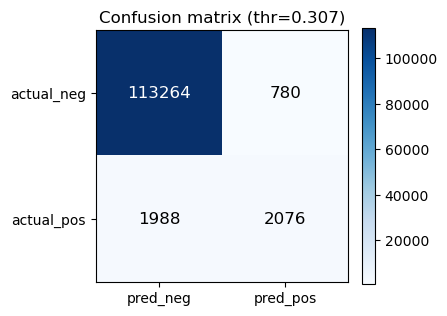

In [32]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, precision_recall_curve
import matplotlib.pyplot as plt

val_pred = m.predict_proba(X_val_run)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, val_pred)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = f1[:-1].argmax()
best_thr = thr[best_idx]
print(f'Best-F1 threshold : {best_thr:.4f}  | precision {prec[best_idx]:.4f}  recall {rec[best_idx]:.4f}  F1 {f1[best_idx]:.4f}')

for t in [0.1, 0.2, 0.3, 0.5, best_thr]:
    y_hat = (val_pred >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_val, y_hat, average='binary', zero_division=0)
    print(f'thr={t:.4f} | precision={p:.4f} recall={r:.4f} F1={f:.4f}')

y_hat = (val_pred >= best_thr).astype(int)
cm = confusion_matrix(y_val, y_hat)
tn, fp, fn, tp = cm.ravel()
print(f'\nConfusion matrix @ thr={best_thr:.4f}')
print(pd.DataFrame(cm, index=['actual_neg','actual_pos'], columns=['pred_neg','pred_pos']))
print(f'\nTN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Fraud catch rate (recall) : {tp/(tp+fn):.4f}')
print(f'False-alarm rate          : {fp/(fp+tn):.4f}')

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(['pred_neg', 'pred_pos'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['actual_neg', 'actual_pos'])
ax.set_title(f'Confusion matrix (thr={best_thr:.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


### Feature importance

In [33]:
importance = (pd.DataFrame({
    'feature':    feats_run,
    'importance': m.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True))

print('=== Top 40 ===')
print(importance.head(40).to_string(index=False))

print('\n=== New profile features ===')
print(importance[importance['feature'].isin(new_feat)].to_string(index=False))


=== Top 40 ===
                    feature  importance
                amt_decimal        2384
user_id1_TransactionAmt_sum         735
              TransactionDT         693
                      id_31         608
user_id1_TransactionAmt_max         589
           user_id1_C13_sum         530
user_id1_TransactionAmt_min         518
           user_id1_C13_max         493
             TransactionAmt         474
user_id1_TransactionAmt_p25         463
user_id1_TransactionAmt_p50         419
user_id1_TransactionAmt_avg         400
user_id3_TransactionAmt_max         396
           user_id3_C13_avg         365
         user_id3_dist1_avg         360
         user_id3_dist1_p75         356
user_id1_TransactionAmt_p75         354
user_id3_TransactionAmt_avg         353
   card1_TransactionAmt_max         353
   card2_TransactionAmt_max         344
         user_id1_dist1_max         344
                        D15         344
         user_id3_dist1_max         342
              card1_C13_a

### Generate submission

In [60]:
X_test_run = test_s[feats_run].copy()
test_pred  = m.predict_proba(X_test_run)[:, 1]

submission = pd.DataFrame({
    'TransactionID': test_s['TransactionID'].values,
    'isFraud':       test_pred
})

test_original_order = test_transaction['TransactionID'].values
submission = submission.set_index('TransactionID').loc[test_original_order].reset_index()

submission.to_csv('submission_v7.csv', index=False)
print(f'Saved: {submission.shape}')
print(submission['isFraud'].describe().round(4))


Saved: (506691, 2)
count    506691.0000
mean          0.0315
std           0.1196
min           0.0003
25%           0.0021
50%           0.0045
75%           0.0119
max           0.9965
Name: isFraud, dtype: float64


In [98]:
train_out[['user_id1','user_id2','user_id3','user_id4']]

,user_id1,user_id2,user_id3,user_id4
0,13926_315.0_-13.0,13926_nan,13926_315.0,13926_315.0_nan
1,2755_325.0_1.0,2755_404.0,2755_325.0,2755_325.0_gmail.com
2,4663_330.0_1.0,4663_490.0,4663_330.0,4663_330.0_outlook.com
3,18132_476.0_-111.0,18132_567.0,18132_476.0,18132_476.0_yahoo.com
4,4497_420.0_1.0,4497_514.0,4497_420.0,4497_420.0_gmail.com
...,...,...,...,...
590535,6550_272.0_153.0,6550_nan,6550_272.0,6550_272.0_nan
590536,10444_204.0_182.0,10444_225.0,10444_204.0,10444_204.0_gmail.com
590537,12037_231.0_182.0,12037_595.0,12037_231.0,12037_231.0_gmail.com
590538,7826_387.0_160.0,7826_481.0,7826_387.0,7826_387.0_aol.com


In [106]:
edge_cols

#print("Fraud rate:", train_csv['isFraud'].mean())


['user_id1', 'user_id3', 'card1', 'card2', 'addr1']

### Download features

Export `features + new_feat` for train (tr + val) and test as CSV.
Train includes `isFraud` label; test does not.

In [101]:
# ── combine tr + val as full train output ─────────────────────────────────

export_feats = features + new_feat +edge_cols  # features + new_feat from baseline cell

train_out = pd.concat([tr_s, val_s], ignore_index=True)
test_out  = test_s.copy()

# train: features + label
train_csv = train_out[export_feats].copy()
train_csv.insert(0, 'TransactionID', train_out['TransactionID'].values)
train_csv['isFraud'] = train_out['isFraud'].values

# test: features only (no label)
test_csv = test_out[export_feats].copy()
test_csv.insert(0, 'TransactionID', test_out['TransactionID'].values)

# save
train_csv.to_csv('train_features_v631.csv', index=False)
test_csv.to_csv('test_features_v631.csv',  index=False)

print(f'train_features_v6.csv : {train_csv.shape}  '
      f'(cols: {train_csv.shape[1]-2} features + TransactionID + isFraud)')
print(f'test_features_v6.csv  : {test_csv.shape}  '
      f'(cols: {test_csv.shape[1]-1} features + TransactionID)')
print(f'\nFeature list ({len(export_feats)} total):')
print(export_feats)

# preview
print('\n── Train preview ──')
print(train_csv.head(3).to_string())
print('\n── Test preview ──')
print(test_csv.head(3).to_string())


train_features_v6.csv : (590540, 638)  (cols: 636 features + TransactionID + isFraud)
test_features_v6.csv  : (506691, 637)  (cols: 636 features + TransactionID)

Feature list (636 total):
['TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V66', 'V67', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V90', 